<a href="https://colab.research.google.com/github/Aymen-dev-ma/DRL/blob/master/scm_traffic_lights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pgmpy
from pgmpy.models import BayesianModel
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
import pandas as pd

# Define the structure of the SCM
model = BayesianModel([
    ('TimeOfDay', 'TrafficLight'),
    ('AlcoholConsumption', 'ReactionTime'),
    ('CrowdDensity', 'ReactionTime'),
    ('TrafficLight', 'Action'),
    ('ReactionTime', 'Action'),
    ('Action', 'Outcome'),
    ('TrafficLight', 'Outcome')
])

# Define the CPDs (Conditional Probability Distributions)
cpd_time_of_day = TabularCPD(variable='TimeOfDay', variable_card=2, values=[[0.7], [0.3]])  # 0: Day, 1: Night
cpd_alcohol_consumption = TabularCPD(variable='AlcoholConsumption', variable_card=2, values=[[0.8], [0.2]])  # 0: Sober, 1: Drunk
cpd_crowd_density = TabularCPD(variable='CrowdDensity', variable_card=2, values=[[0.6], [0.4]])  # 0: Low, 1: High

# Traffic light depends on time of day
cpd_traffic_light = TabularCPD(variable='TrafficLight', variable_card=2,
                               values=[[0.8, 0.2],  # Day: Green, Night: Green
                                       [0.2, 0.8]],  # Day: Red, Night: Red
                               evidence=['TimeOfDay'], evidence_card=[2])

# Reaction time depends on alcohol consumption and crowd density
cpd_reaction_time = TabularCPD(variable='ReactionTime', variable_card=2,
                               values=[[0.9, 0.7, 0.6, 0.4],  # Sober-Low, Sober-High, Drunk-Low, Drunk-High
                                       [0.1, 0.3, 0.4, 0.6]],  # Slow Reaction Time
                               evidence=['AlcoholConsumption', 'CrowdDensity'], evidence_card=[2, 2])

# Action depends on traffic light and reaction time
cpd_action = TabularCPD(variable='Action', variable_card=2,
                        values=[[0.95, 0.5, 0.8, 0.2],  # Green-Fast, Green-Slow, Red-Fast, Red-Slow
                                [0.05, 0.5, 0.2, 0.8]],  # Walk, Stop
                        evidence=['TrafficLight', 'ReactionTime'], evidence_card=[2, 2])

# Outcome depends on action and traffic light
cpd_outcome = TabularCPD(variable='Outcome', variable_card=3,
                         values=[[0.9, 0.7, 0.5, 0.2],  # Safe: Walk-Green, Walk-Red, Stop-Green, Stop-Red
                                 [0.05, 0.2, 0.3, 0.5],  # Injury
                                 [0.05, 0.1, 0.2, 0.3]],  # Accident
                         evidence=['Action', 'TrafficLight'], evidence_card=[2, 2])

# Add the CPDs to the model
model.add_cpds(cpd_time_of_day, cpd_alcohol_consumption, cpd_crowd_density,
               cpd_traffic_light, cpd_reaction_time, cpd_action, cpd_outcome)

# Validate the model
assert model.check_model()

# Inferencing using the model
inference = VariableElimination(model)


  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinu

In [3]:
import numpy as np

# Define the size of the dataset
data_size = 1000

# Sample from the defined model
samples = inference.query(variables=['TimeOfDay', 'AlcoholConsumption', 'CrowdDensity', 'TrafficLight', 'ReactionTime', 'Action', 'Outcome'],
                          joint=True, show_progress=False).sample(data_size)

# Convert to a DataFrame
df = pd.DataFrame(samples, columns=['TimeOfDay', 'AlcoholConsumption', 'CrowdDensity', 'TrafficLight', 'ReactionTime', 'Action', 'Outcome'])

# Replace categorical values with labels for clarity
df['TimeOfDay'] = df['TimeOfDay'].map({0: 'Day', 1: 'Night'})
df['AlcoholConsumption'] = df['AlcoholConsumption'].map({0: 'Sober', 1: 'Drunk'})
df['CrowdDensity'] = df['CrowdDensity'].map({0: 'Low', 1: 'High'})
df['TrafficLight'] = df['TrafficLight'].map({0: 'Green', 1: 'Red'})
df['ReactionTime'] = df['ReactionTime'].map({0: 'Fast', 1: 'Slow'})
df['Action'] = df['Action'].map({0: 'Walk', 1: 'Stop'})
df['Outcome'] = df['Outcome'].map({0: 'Safe', 1: 'Injury', 2: 'Accident'})

# Display the generated dataset
print(df.head())


  TimeOfDay AlcoholConsumption CrowdDensity TrafficLight ReactionTime Action  \
0       Day              Drunk          Low        Green         Fast   Walk   
1     Night              Sober         High          Red         Fast   Walk   
2       Day              Sober          Low        Green         Fast   Walk   
3     Night              Sober         High          Red         Fast   Walk   
4       Day              Sober         High        Green         Fast   Walk   

    Outcome  
0      Safe  
1      Safe  
2      Safe  
3  Accident  
4      Safe  


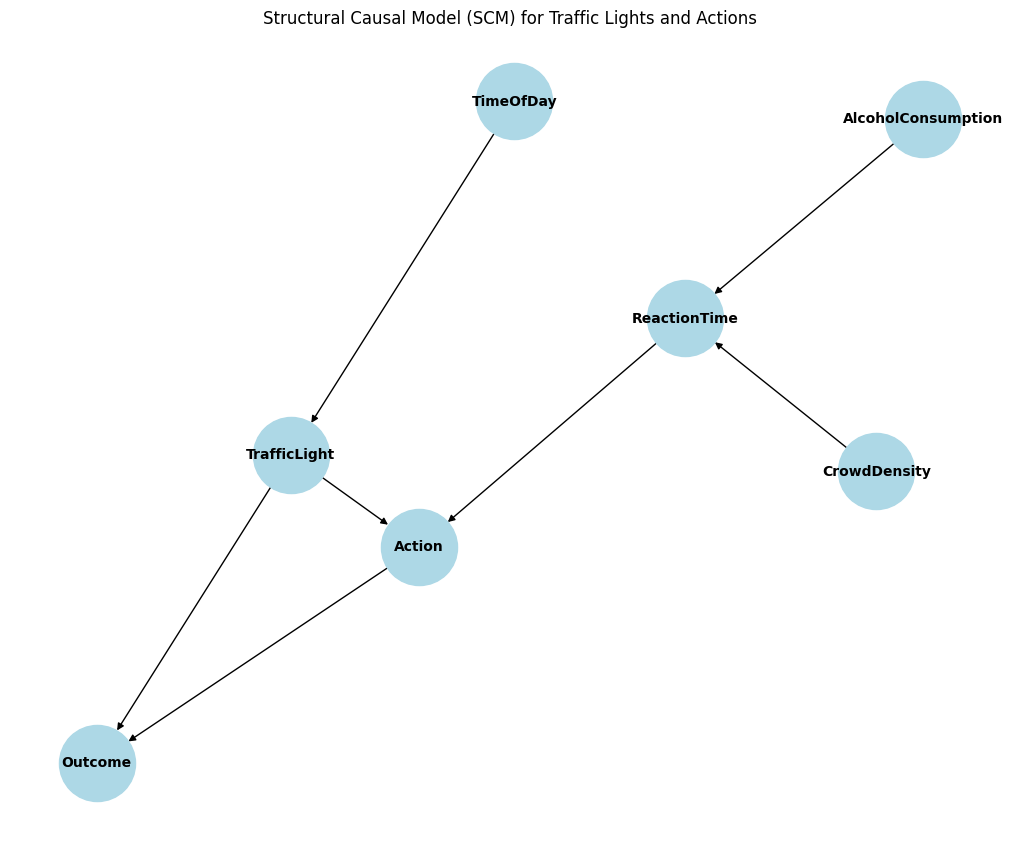

In [6]:
# Define the edges manually
edges = [
    ('TimeOfDay', 'TrafficLight'),
    ('AlcoholConsumption', 'ReactionTime'),
    ('CrowdDensity', 'ReactionTime'),
    ('TrafficLight', 'Action'),
    ('ReactionTime', 'Action'),
    ('Action', 'Outcome'),
    ('TrafficLight', 'Outcome')
]

# Create a directed graph
G = nx.DiGraph()
G.add_edges_from(edges)

# Draw the graph
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="lightblue", font_size=10, font_weight="bold", arrows=True)
plt.title('Structural Causal Model (SCM) for Traffic Lights and Actions')
plt.show()


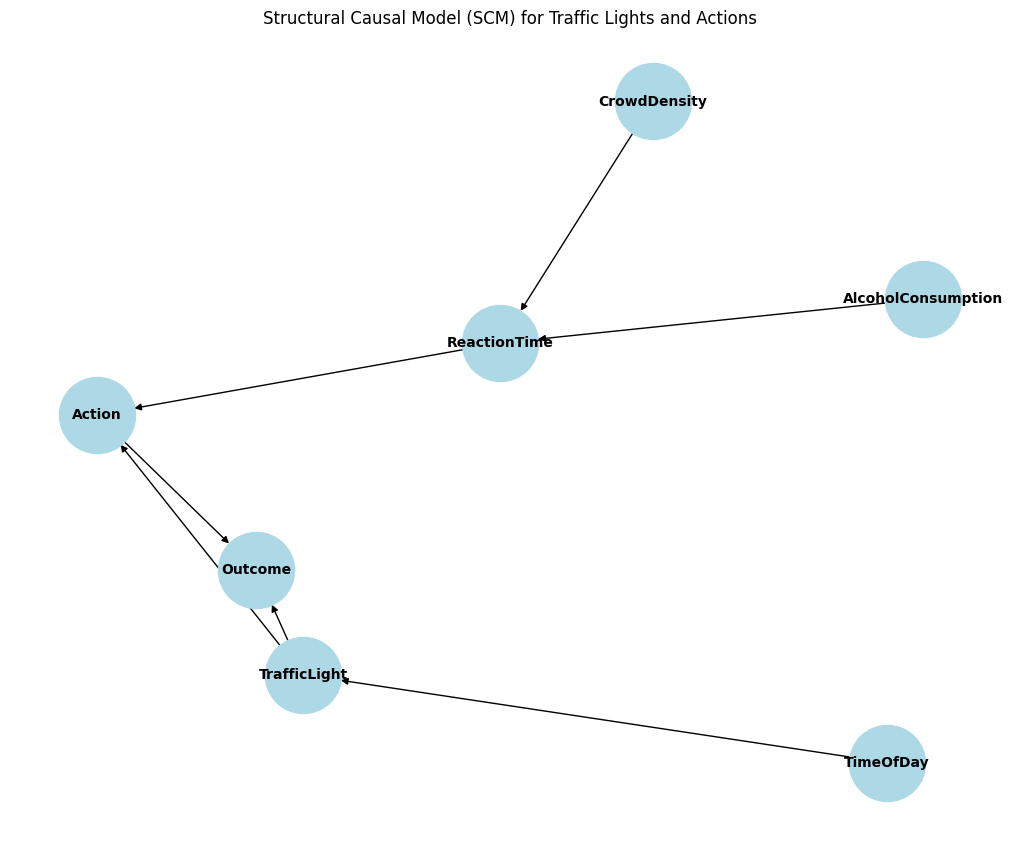

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

# Extract the edges from the BayesianModel
edges = model.edges()

# Create a directed graph in networkx using the extracted edges
G = nx.DiGraph(edges)

# Draw the graph using networkx
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G)  # Use a layout for a better visualization
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="lightblue", font_size=10, font_weight="bold", arrows=True)
plt.title('Structural Causal Model (SCM) for Traffic Lights and Actions')
plt.show()


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Prepare the data for training
X = df[['TimeOfDay', 'AlcoholConsumption', 'CrowdDensity', 'TrafficLight', 'ReactionTime']]
y = df['Outcome']

# Convert categorical variables into dummy/indicator variables
X = pd.get_dummies(X)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a decision tree classifier
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

# Predict on the test set
y_pred = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')


Accuracy: 0.74


In [10]:
##pruning the confoundersfrom sklearn.linear_model import LassoCV
from sklearn.linear_model import LassoCV  # Import LassoCV
import pandas as pd

# Assuming df is the dataset generated earlier
X = pd.get_dummies(df[['TimeOfDay', 'AlcoholConsumption', 'CrowdDensity', 'TrafficLight', 'ReactionTime']])
y = df['Outcome'].apply(lambda x: 1 if x == 'Safe' else 0)  # Binary outcome

# Apply Lasso for feature selection
lasso = LassoCV(cv=5).fit(X, y)
importance = pd.Series(lasso.coef_, index=X.columns)

# Display the coefficients
print("Lasso coefficients for confounders and actions:")
print(importance)

# Prune confounders with near-zero coefficients
pruned_conf = importance[importance != 0].index.tolist()
print(f"Confounders after pruning: {pruned_conf}")


Lasso coefficients for confounders and actions:
TimeOfDay_Day               0.000000e+00
TimeOfDay_Night            -0.000000e+00
AlcoholConsumption_Drunk    0.000000e+00
AlcoholConsumption_Sober   -0.000000e+00
CrowdDensity_High          -4.612355e-03
CrowdDensity_Low            4.322292e-17
TrafficLight_Green          2.691047e-01
TrafficLight_Red           -3.084208e-16
ReactionTime_Fast           2.120291e-01
ReactionTime_Slow          -1.013063e-16
dtype: float64
Confounders after pruning: ['CrowdDensity_High', 'CrowdDensity_Low', 'TrafficLight_Green', 'TrafficLight_Red', 'ReactionTime_Fast', 'ReactionTime_Slow']


In [11]:
import statsmodels.api as sm

# Fit a logistic regression model with all confounders
X = pd.get_dummies(df[['TimeOfDay', 'AlcoholConsumption', 'CrowdDensity', 'TrafficLight', 'ReactionTime']])
y = df['Outcome'].apply(lambda x: 1 if x == 'Safe' else 0)  # Binary outcome
X = sm.add_constant(X)

# Fit the model
model = sm.Logit(y, X).fit()

# Display p-values
print(model.summary())

# Start backward elimination based on p-values
while model.pvalues.max() > 0.05:
    worst_conf = model.pvalues.idxmax()
    X = X.drop(columns=[worst_conf])
    model = sm.Logit(y, X).fit()

print("Final model after backward elimination:")
print(model.summary())


ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).